**主要变量说明**  
| 变量名 | 含义描述 | 来源 | 数据格式 |
|------|----------|------|----------|
| Event | 某次实验完整的事件字典 | pkl 文件读入（来自 `Process.ipynb`） | `dict{event1, event2, ...}` |
| event | Event 中的某一类具体事件 | `Event['keyword']` | `dict{"Time_S": [ts1,ts3,...], "Time_E": [ts2,ts4,...]}` |
| eve_list | Event 中所有事件按时间顺序整理后的列表 | `behave_ana.sort_events()` | `list[(ts1, event), (ts2, event), ...]` |
| trial_sequence | 每一次尝试具体的结果信息 | `behave_ana.transform_sequence()` | `list[(ts,is_correct,correct_side,reward_or_not),...]` |

_*ts指 timestamp_

In [3]:
import pickle
import behave_ana
import pandas as pd
import os
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
from scipy.stats import zscore,entropy
from scipy.signal import find_peaks
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass


**查找文件**  
找到指定路径下的pkl文件

In [4]:
from pathlib import Path
path = "/home/zyyk78/HDD/zyyk78/MPtest"
path = Path(path)
pkl_files = list(path.rglob("*.pkl"))
for file in pkl_files:
    print(file)


/home/zyyk78/HDD/zyyk78/MPtest/B02/20250715_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251129SS9R25p_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250924S7_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251124SS9R50p_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251024SS9L_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250803T7_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250911T9_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250915T5_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250802T7_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251202SS7R12p_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251203SS9L12p_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251027SS9R25p_01.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250721R_01.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251127SS9R25p_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250925S7_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250720F_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20251222AC7L_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/B02/20250814T7_00.pkl
/home/zyyk78/HDD

**数据导入和基础统计**  
把pkl路径弄到excel里面,然后把想分析的那一堆copy下就行了

In [5]:
def cumulative_correct_auc(eve_list):#累计正确AUC
    correct_events = {"SlnL", "SlnR"}
    correct = [
        (t, e) for t, e in eve_list
        if e in correct_events
    ]

    if len(correct) < 2:
        return np.nan

    times = np.array([t for t, _ in correct])

    t0 = times[0]
    t1 = times[-1]

    x = (times - t0) / (t1 - t0)        # 归一化时间
    y = np.arange(1, len(times) + 1)    # 累计正确数
    y = y / y[-1]                       # 归一化累计正确

    auc = np.trapz(y, x)
    return auc

In [ ]:
# 从剪贴板读取Excel复制的数据（自动检测分隔符）
# df = pd.read_clipboard(header=None) 
# 转换为列表（每行一个子列表）
# matches = df.values.tolist()  

df = """
/home/zyyk78/HDD/zyyk78/MPtest/G01/20251023T9_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/G03/20251023T9_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/G04/20251023T9_00.pkl
/home/zyyk78/HDD/zyyk78/MPtest/G02/20251023T9_00.pkl
""".strip()  # strip()去除首尾空行
matches = [[path.strip()] for path in df.split("\n")]

data_collect = []
for pkl_path in matches:
    with open(pkl_path[0],"rb") as pkl_f:
        Event=pickle.load(pkl_f)
        long_event=['MinT','Blackhole']
        ignore_list=['MinS','CamT','LickL','LickR','tMod']
        eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
        date_info=os.path.basename(pkl_path[0])
        date_info=str.split(date_info,'_')[0]

        tot_rew = tca_auc = cc_auc = log_lr = tot_acc = lrn_auc = avg_licks_after_reward = avg_licks_after_noreward = 0

        try:
            _,_,tot_rew=behave_ana.reward_rate(Event)
            tca_auc = behave_ana.cumulative_attempt_auc(eve_list)
            cc_auc = cumulative_correct_auc(eve_list)
            log_lr = behave_ana.log_lr(eve_list)
        except:
            pass
            
        if Event['ModL']['Time_S']==[] and Event['ModR']['Time_S']==[]:
            tot_acc=0
        else:
            _,_,tot_acc=behave_ana.accuracy_rate(eve_list)
            trial_sequence = behave_ana.transform_sequence(eve_list)
            lrn_auc = behave_ana.learning_auc(trial_sequence)
            avg_licks_after_reward, avg_licks_after_noreward, total_lick_events = behave_ana.licking_rate(Event, eve_list)
            
            # hr,hn,lr,ln = (0,0,0,0)
            # for is_high,_,is_rew in trial_sequence:
            #     if is_high and is_rew:
            #         hr+=1
            #     elif is_high and not is_rew:
            #         hn+=1
            #     elif not is_high and is_rew:
            #         lr+=1
            #     elif not is_high and not is_rew:
            #         ln+=1
            # print(hr,hn,lr,ln)
            
        all_data={
            'date':date_info,
            'tot_rew':tot_rew,
            'tot_acc':tot_acc,
            'lrn_auc' : lrn_auc,
            'tca_auc' :tca_auc,
            'cc_auc':cc_auc,
            'log_lr' : log_lr,
            'eve_list':eve_list,
            'avg_licks_after_reward':avg_licks_after_reward,
            'avg_licks_after_noreward':avg_licks_after_noreward
        }
        
        data_collect.append(all_data)

In [ ]:
#两项简单的统计参数:tot_rew,tot_acc等参数,需要看哪个就打印出来
for data in data_collect:
    print(data['lrn_auc'],average(data['lrn_auc']))


0.5711371141537149
0.6039691751931845
0.3562303963984166
0.5564913799244693


In [ ]:
A_sl=[]
A_err=[]
A_lick_rate=[]
for data in data_collect:
    eve_list=data['eve_list']
    lat_data = behave_ana.get_switching_latency(eve_list)
    if len(lat_data) > 0 :
        A_sl.append(sum([i[0] for i in lat_data])/len(lat_data))
        A_err.append(sum([(len(i)-1)/2 for i in lat_data])/len(lat_data))
        lick_event = [ i for i in eve_list if i[1] in ['ROmL','ROmR','SlnL','SlnR'] ]
        A_lick_rate.append( (lick_event[-1][0] - lick_event[0][0]) /  (len(lick_event) * 50000) )
    else:
        A_sl.append(0)
        A_err.append(0)
        A_lick_rate.append(0)

In [ ]:
#同样, A_sl/A_err 和 A_lick_rate 需要那个打印哪个
for i in A_lick_rate:
    print(i)

In [26]:
Evnet_idx = 2
pkl_path = matches[Evnet_idx]
with open(pkl_path[0],"rb") as pkl_f:
    Event=pickle.load(pkl_f)
eve_list = data_collect[Evnet_idx]['eve_list']

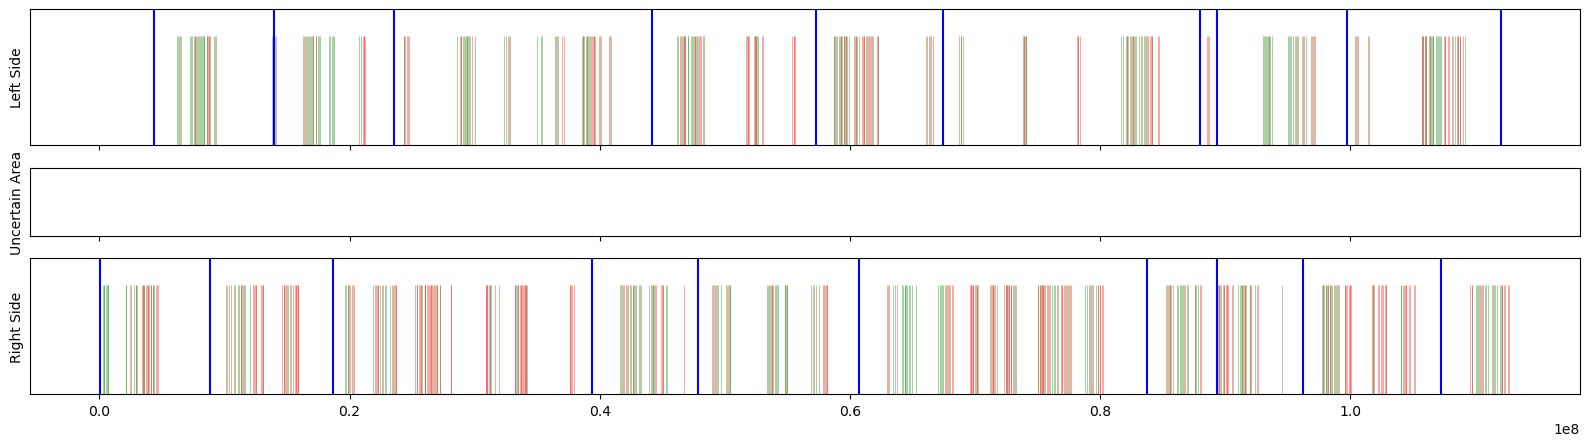

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
    
fig, (ax1, ax1_5, ax2) = plt.subplots(3, 1, figsize=(20, 5), 
                                   gridspec_kw={'height_ratios': [2 , 1 , 2]},sharex=True,)
sns.rugplot(Event['SlnL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['SlnR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['ROmL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ROmR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ModL']['Time_S'] , ax=ax1, height=1, linewidth=1.5, color='blue')
sns.rugplot(Event['ModR']['Time_S'] , ax=ax2, height=1, linewidth=1.5, color='blue')

if 'Blackhole' in Event:
    for i in range(len(Event['Blackhole']['Time_S'])):
        ax1_5.fill_betweenx(y=[-0.5, 0.5], x1 = Event['Blackhole']['Time_S'][i], x2=Event['Blackhole']['Time_E'][i],color='red')
ax1.set_yticks([])
ax1.set_ylabel('Left Side')
ax2.set_yticks([])
ax2.set_ylabel('Right Side')
ax1_5.set_yticks([])
ax1_5.set_ylabel('Uncertain Area')
plt.show()

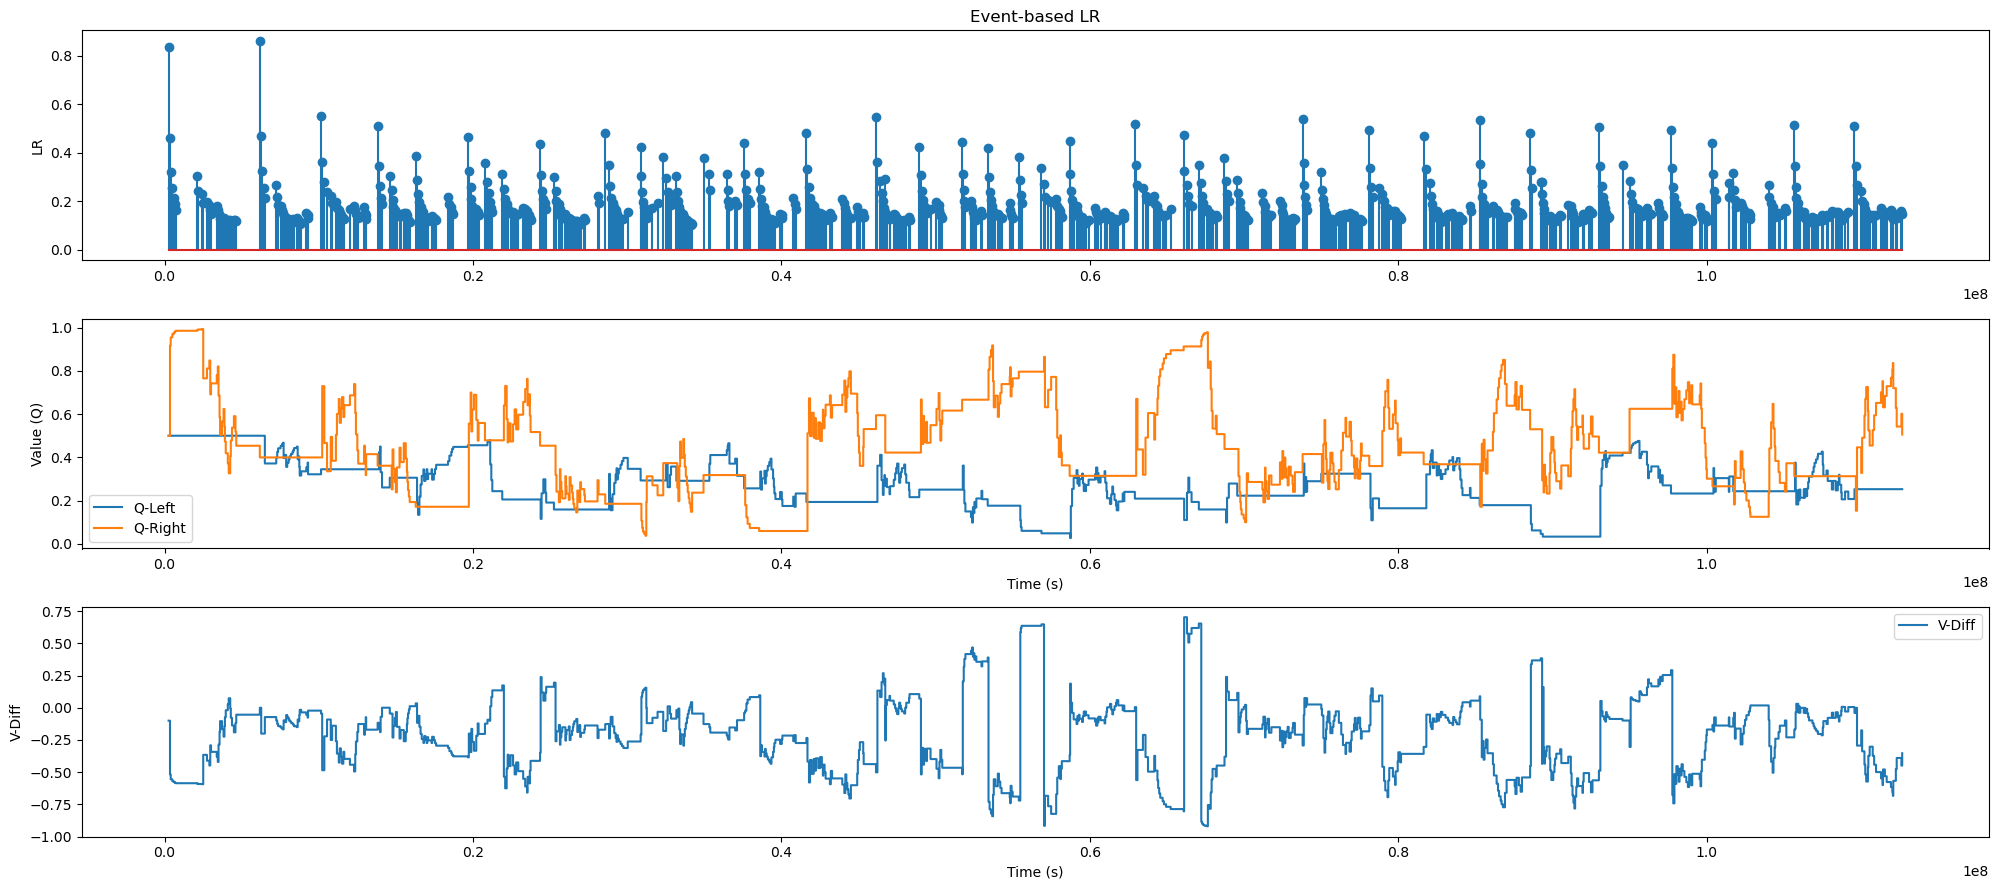

In [43]:
def compute_rl_dynamics(raw_eve_list, cost_switch, obs_noise, proc_noise, initial_q=0.5,RewardLR=(0.5,1)):
    """
    针对格式为 [(ts, event), ...] 的 eve_list 进行 RL 动力学计算
    """
    # --- 1. 数据预解析 ---
    # 仅提取行为事件，并解析为 (ts, action, reward)
    processed_events = []
    for ts, event in raw_eve_list:
        if event in ['SlnL', 'ROmL', 'SlnR', 'ROmR']:
            a = 0 if 'L' in event else 1
            if 'Sln' in event:
                r =  RewardLR[0] if a == 0 else RewardLR[1]
            else:
                r = 0
            processed_events.append((ts, a, r))
    
    num_events = len(processed_events)
    if num_events == 0:
        return None

    # --- 2. 结果容器 ---
    results = {
        "ts": np.zeros(num_events),
        "alpha": np.zeros(num_events),
        "rpe": np.zeros(num_events),
        "q_left": np.zeros(num_events),
        "q_right": np.zeros(num_events),
        "v_diff": np.zeros(num_events),  # 决策变量
        "is_switch": np.zeros(num_events, dtype=bool)
    }

    # --- 3. 初始状态 ---
    q_vals = np.array([initial_q, initial_q])
    uncertainty = np.array([0.5, 0.5])
    
    # 初始位置：根据第一个行为事件判定
    _, first_a, _ = processed_events[0]
    current_side = first_a 
    last_ts = processed_events[0][0]

    # --- 4. 迭代计算 ---
    for i in range(num_events):
        ts, a, r = processed_events[i]
        dt = ts - last_ts
        
        # A. 预测步：不确定性随时间流逝增加
        uncertainty += proc_noise * dt
        
        # B. 决策变量计算 (在看到结果更新 Q 之前)
        # 计算基于小鼠“当前所在侧”的决策压力
        q_stay = q_vals[current_side]
        q_switch = q_vals[1 - current_side]
        # v_diff = (目标侧价值 - 成本) - 当前侧价值
        v_diff = (q_switch - cost_switch) - q_stay
        
        # C. 更新步 (Kalman Update)
        alpha = uncertainty[a] / (uncertainty[a] + obs_noise)
        rpe = r - q_vals[a]
        
        # 记录结果
        results["ts"][i] = ts
        results["alpha"][i] = alpha
        results["rpe"][i] = rpe
        results["v_diff"][i] = v_diff
        results["q_left"][i] = q_vals[0]
        results["q_right"][i] = q_vals[1]
        # 判定是否发生了位置切换 (即本次舔的侧与上次所在侧不同)
        results["is_switch"][i] = (a != current_side)
        
        # 实际更新 Q 值和不确定性
        q_vals[a] += alpha * rpe
        uncertainty[a] *= (1 - alpha)
        
        # D. 状态更新
        current_side = a # 记录小鼠现在所处的水嘴位置
        last_ts = ts
        
    return results

res = compute_rl_dynamics(eve_list, cost_switch=0.1, obs_noise=0.1, proc_noise=0.001/50000)

plt.figure(figsize=(20, 9))
plt.subplot(3, 1, 1)
plt.stem(res['ts'], res['alpha'])
plt.title('Event-based LR')
plt.ylabel('LR')

plt.subplot(3, 1, 2)
plt.step(res['ts'], res['q_left'], label='Q-Left', where='post')
plt.step(res['ts'], res['q_right'], label='Q-Right', where='post')
plt.legend()
plt.ylabel('Value (Q)')
plt.xlabel('Time (s)')

plt.subplot(3, 1, 3)
plt.step(res['ts'], res['v_diff'], label='V-Diff', where='post')
plt.legend()
plt.ylabel('V-Diff')
plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()

**自回归分析**  
这里只依赖前面载入的pkl文件  
统计这些pkl中选择的历史以来情况

In [ ]:
fig_bys,ax_bys=plt.subplots(figsize=(8, 5),dpi=300)

para_list=[]
bias_list=[]
acc_list=[]
for i in range(1000):
    sw_seq= []
    ns_seq= []
    for data_dict in data_collect:
        sw=behave_ana.get_switch_sequence(data_dict['eve_list'],10)
        sw_seq.extend(sw)
        ns_seq.extend(behave_ana.get_random_ns_sequence(data_dict['eve_list'],10,len(sw)))
    para,bias,acc=behave_ana.switch_bayes_reg(sw_seq,ns_seq)
    para_list.append(para)
    bias_list.append(bias)
    acc_list.append(acc)
para_list=np.array(para_list)
bias_list=np.array(bias_list)
acc_list=np.array(acc_list)

means = np.mean(para_list, axis=0)[0]
stds = np.std(para_list, axis=0)[0]
means_bias = np.mean(np.squeeze(bias_list))
stds_bias = np.std(np.squeeze(bias_list))
means_acc = np.mean(np.squeeze(acc_list))
stds_acc = np.std(np.squeeze(acc_list))

x = [i for i in range(-means.shape[0],0)]

# 绘制误差线折线图len_lat_data
ax_bys.errorbar(
    [i for i in range(-means.shape[0],0)],   
    y=means, 
    yerr=stds,
    fmt='-o',         # 线型：实线+圆圈标记
    capsize=5,        # 误差线端盖长度
    capthick=2,       # 端盖粗细
    elinewidth=1,     # 误差线粗细
    label='coef ± Std, Expert'
)

ax_bys.errorbar(
    0, 
    y=means_bias, 
    yerr=stds_bias,
    fmt='-o',         # 线型：实线+圆圈标记
    capsize=5,        # 误差线端盖长度
    capthick=2,       # 端盖粗细
    elinewidth=1,     # 误差线粗细
    label='bias ± Std, Expert'
)
ax_bys.axhline(y=0, color='red', linewidth=3, linestyle='-')
print(f'Pred_Acc={means_acc:.2f}±{stds_acc:.2f}')

ax_bys.set_ylabel('Coefficient')
ax_bys.set_xlabel('Trial')
ax_bys.set_title('Logistic Autoregression Coefficient, Bootstrap=1000')
ax_bys.set_ylim(-3, 3)
legend=ax_bys.legend()
display(fig_bys)

**显著性分析比对**   
需要你copy一个表格(直接从excel中框选复制即可)  
参考格式如下:

| Tag | Reward Ratio | Accuracy | Switching Latency | Incorrect Switch | Trial Gap |
|-----|--------------|----------|-------------------|------------------|-----------|
| T8  | 0.534460338  | 0.613312203 | 6.117647059  | 1.441176471  | 3.340758352 |
| T8  | 0.482142857  | 0.18907563  | 16            | 2.357142857  | 2.369864286 |
| T8  | 0.60960961   | 0.599099099 | 9.866666667  | 1.033333333  | 1.945558799 |
| T8  | 0.56097561   | 0.561683599 | 12.73333333  | 0.933333333  | 2.555443079 |
| T9  | 0.489671932  | 0.413122722 | 13            | 1.818181818  | 3.237225881 |
| T9  | 0.363471971  | 0.121661721 | 13.25         | 4.375         | 4.492284458 |
| T9  | 0.520779221  | 0.507792208 | 4.875         | 6.6875        | 3.156573948 |
| T9  | 0.24504084   | 0.175029172 | 5.333333333  | 14.33333333  | 4.780938203 |
  
_并且接下来还有一些要对应修改的_

In [ ]:
ref_tag= 'T9'  #这个是进行显著性分析的参考项
feature_columns = ['Reward Ratio', 'Accuracy', 'Switching Latency', 'Incorrect Switch', 'Trial_Gap']
STAT_TEST = lambda x, y: stats.mannwhitneyu(x, y, alternative="two-sided")  # M-W U-Test
#STAT_TEST = lambda x, y: stats.ttest_ind(x,y)  #T-Test

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# 从剪贴板读取数据
df = pd.read_clipboard()

# 查看数据结构
print("数据前几行：")
print(df.head())
print("\n数据信息：")
print(df.info())

# 检查数据列名
print("\n数据列名：")
print(df.columns.tolist())


# 数据整理
df_melted = df.melt(id_vars=['Tags'], value_vars=feature_columns, 
                    var_name='Data_Type', value_name='Value')

# 统计检验 - 对每个数据类型，将每个组与ref_tag进行比较
test_results = {}

for data_type in feature_columns:
    data_subset = df_melted[df_melted['Data_Type'] == data_type]
    T9_data = data_subset[data_subset['Tags'] == ref_tag]['Value'].values
    
    # 获取所有唯一的标签
    other_tags = [tag for tag in data_subset['Tags'].unique() if tag != ref_tag]
    
    results = {}
    for tag in other_tags:
        tag_data = data_subset[data_subset['Tags'] == tag]['Value'].values
        if len(T9_data) > 0 and len(tag_data) > 0:
            _, p_value = STAT_TEST(T9_data, tag_data)
            results[tag] = p_value
    
    test_results[data_type] = results

print("\nT检验结果：")
for data_type, tag_results in test_results.items():
    print(f"\n{data_type}:")
    for tag, p_val in tag_results.items():
        print(f"  {tag} vs T9: p-value = {p_val:.4f}")

# 创建图形 - 5个特征，使用2x3的布局
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 设置颜色 - 使用seaborn默认调色板
unique_tags = df['Tags'].unique()
palette = sns.color_palette("Set2", len(unique_tags))



# 为每个特征绘制箱型图
for i, feature in enumerate(feature_columns):
    if i < len(axes):
        ax = axes[i]
        step_height = 0
        # 绘制箱型图
        sns.boxplot(data=df, x='Tags', y=feature, ax=ax, palette=palette)
        sns.stripplot(data=df, x='Tags', y=feature, ax=ax, color='black', alpha=0.6, size=4, jitter=True)
        
        # 标注显著性
        if feature in test_results:
            y_max = df[feature].max()
            y_min = df[feature].min()
            y_range = y_max - y_min
            
            # 为每个非T9标签添加显著性标注
            x_positions = {}
            for j, tag in enumerate(unique_tags):
                x_positions[tag] = j
            
            T9_position = x_positions[ref_tag]
            
            for tag, p_value in test_results[feature].items():
                if tag in x_positions:
                    tag_position = x_positions[tag]
                    mid_point = (T9_position + tag_position) / 2
                    
                    # 计算标注位置
                    significance_y = y_max + 0.1 * y_range + step_height*0.1*y_range
                    
                    # 添加显著性符号
                    if p_value < 0.001:
                        symbol = '***'
                    elif p_value < 0.01:
                        symbol = '**'
                    elif p_value < 0.05:
                        symbol = '*'
                    else:
                        symbol = 'ns'
                    
                    # 添加横线和标注
                    ax.plot([T9_position, tag_position], [significance_y , significance_y ], 'k-', lw=1)
                    ax.plot([T9_position, T9_position], [significance_y-0.01*y_range , significance_y ], 'k-', lw=1)
                    ax.plot([tag_position, tag_position], [significance_y-0.01*y_range , significance_y ], 'k-', lw=1)
                    ax.text(mid_point, significance_y + 0.02*y_range , symbol, 
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
                step_height += 1      
        
        ax.set_title(f'{feature} Distribution', fontsize=14, fontweight='bold')
        ax.set_ylabel(feature, fontsize=12)
        ax.set_xlabel('Tags', fontsize=12)
        
        # 旋转x轴标签以避免重叠
        ax.tick_params(axis='x', rotation=45)

# 如果子图数量多于特征数量，隐藏多余的子图
for i in range(len(feature_columns), len(axes)):
    axes[i].set_visible(False)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

# 显示描述性统计
print("\n描述性统计：")
desc_stats = df.groupby('Tags')[feature_columns].describe()
print(desc_stats)

# 创建显著性结果表格
print("\n显著性总结（与T9比较）:")
significance_summary = []
for feature in feature_columns:
    if feature in test_results:
        for tag, p_val in test_results[feature].items():
            if p_val < 0.001:
                sig_level = '***'
            elif p_val < 0.01:
                sig_level = '**'
            elif p_val < 0.05:
                sig_level = '*'
            else:
                sig_level = 'ns'
            significance_summary.append({
                'Feature': feature,
                'Comparison': f'{tag} vs T9',
                'p-value': f'{p_val:.4f}',
                'Significance': sig_level
            })

significance_df = pd.DataFrame(significance_summary)
print(significance_df)